In [1]:
import uproot 
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, ReLU
from tensorflow.keras.optimizers import SGD
import tensorflow.keras.layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBClassifier

In [2]:
# Lists to store data from each file
input_list = []
signal_list = []
backgnd_list = []
kQ_list = []

filelist = "KKTrainBkgFiles.txt"
print("Using files in " + filelist)

with open(filelist, 'r') as files:
    for filename in files:
        filename = filename.strip() # Clean up whitespace/newlines
        print("Processing: " + filename)    
        with uproot.open(filename) as file:
            bkgdiag = file["BD"]["bkgcdiag"].arrays()
            
            # Coordinate math
            mmomfX = file["BD"]["bkgcdiag"]['mmom/fCoordinates/fCoordinates.fX'].array()
            mmomfY = file["BD"]["bkgcdiag"]['mmom/fCoordinates/fCoordinates.fY'].array()
            mmomfZ = file["BD"]["bkgcdiag"]['mmom/fCoordinates/fCoordinates.fZ'].array()
            mmomR = np.sqrt(mmomfX**2 + mmomfY**2 + mmomfZ**2)

            # Apply filters
            mask = (bkgdiag['nactive']>=5) & (bkgdiag['np']>=2) & (
                   ((bkgdiag['prel']>=0) & (mmomR > 90)) | 
                   ((bkgdiag['prel']<0) & (abs(bkgdiag['mpdg'])==11) & (mmomR < 20)) | 
                   ((bkgdiag['prel']<0) & (abs(bkgdiag['mpdg'])==2212))
            )
            
            filtered_bkg = bkgdiag[mask]
            
            # Feature Selection (Z-variables as per your logic)
            temp = np.vstack((
                filtered_bkg['crho'].to_numpy(), 
                filtered_bkg['zdiff'].to_numpy(), 
                filtered_bkg['phidiff'].to_numpy(), 
                filtered_bkg['nactive'].to_numpy(),
                filtered_bkg['rmscrho'].to_numpy(),
                filtered_bkg['rmsctime'].to_numpy(), 
                filtered_bkg['rmscphi'].to_numpy(), 
                filtered_bkg['clusterdensity'].to_numpy()
            )).T

            # Extract labels and kQ
            prel = filtered_bkg['prel'].to_numpy()
            kQ = filtered_bkg['kQ'].to_numpy()
            
            # Store in lists
            input_list.append(temp)
            signal_list.append(prel == -2)
            backgnd_list.append(prel >= 0)
            kQ_list.append(kQ)
            
            print(f"Processed {filename}: {temp.shape[0]} hits")

# Final Concatenation
input_dataset = np.concatenate(input_list)
signal = np.concatenate(signal_list)
backgnd = np.concatenate(backgnd_list)
kQ_all = np.concatenate(kQ_list) # Now kQ_all has the same length as signal/backgnd

Using files in KKTrainBkgFiles.txt
Processing: /Users/namithachithirasree/Documents/LBL_projects/KKTrain/RootFiles/nts.owner.BD.version.sequence.root
Processed /Users/namithachithirasree/Documents/LBL_projects/KKTrain/RootFiles/nts.owner.BD.version.sequence.root: 2635262 hits
Processing: /Users/namithachithirasree/Documents/LBL_projects/KKTrain/RootFiles/nts.owner.BD.pbar.sequence.root
Processed /Users/namithachithirasree/Documents/LBL_projects/KKTrain/RootFiles/nts.owner.BD.pbar.sequence.root: 116799 hits


In [3]:
# Calculate length for balancing
# len(input_dataset[signal]) gives the total count of signal hits across ALL files
min_len = min(len(input_dataset[signal]), len(input_dataset[backgnd]))
bsize = 32
tsize = 2 * bsize
min_len = min_len - (min_len % tsize)

print(f"Training on {min_len} matched hits")

# Slice datasets using the full-length kQ_all
signal_dataset = input_dataset[signal][:min_len]
bkg_dataset = input_dataset[backgnd][:min_len]

# FIX: Using the concatenated kQ_all ensures dimensions match
kQCE = kQ_all[backgnd][:min_len]
kQbkge = kQ_all[signal][:min_len]

# Create balanced inputs
balanced_input = np.concatenate((signal_dataset, bkg_dataset))
y_balanced_input = np.concatenate((np.ones(len(signal_dataset)), np.zeros(len(bkg_dataset))))

print(f"Total balanced samples: {len(balanced_input)}")
n_variables = balanced_input.shape[1]
# Train/Test/Valid Splits
from sklearn.model_selection import train_test_split

x_ce_train, x_ce_test, y_ce_train, y_ce_test = train_test_split(
    balanced_input, y_balanced_input, test_size=0.5, random_state=42
)
x_ce_test, x_ce_valid, y_ce_test, y_ce_valid = train_test_split(
    x_ce_test, y_ce_test, test_size=0.5, random_state=42
)

print("Splits complete: Train/Test/Valid distributions are equal.")

Training on 207104 matched hits
Total balanced samples: 414208
Splits complete: Train/Test/Valid distributions are equal.


clusters failed pre sel cuts 0
clusters pass pre sel cuts 116799
pass ratio 1.0


<function matplotlib.pyplot.show(close=None, block=None)>

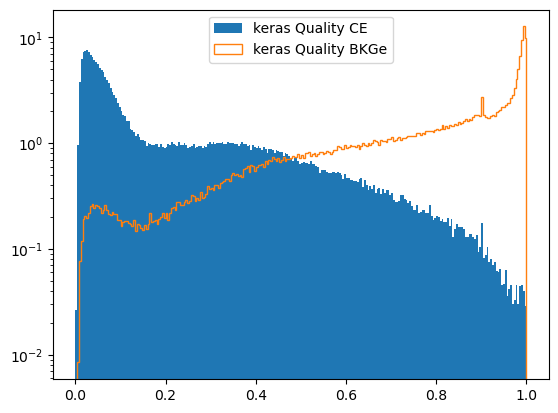

In [4]:
kQpresel = kQ[kQ==-1]
kQpass = kQ[kQ>-1]
print("clusters failed pre sel cuts",len(kQpresel))
print("clusters pass pre sel cuts",len(kQpass))
print("pass ratio", len(kQpass) / len(kQ) )
plt.hist(kQCE,label="keras Quality CE", log=1, bins=250,range=(0,1), density=True)
plt.hist(kQbkge,label="keras Quality BKGe",histtype='step', log=1, bins=250,range=(0,1), density=True)
plt.legend()
plt.show

In [7]:
clusterrho_sig = []
zdiff_sig = []
#deltaPhi_sig = []
phidiff_sig = []
fp_sig = []
lp_sig = []
pgap_sig = []
#nplanes_sig = []
#planefraction_sig = []
nhits_sig = []
rmscrho_sig = []
rmsctime_sig = []
rmscphi_sig = []
clusterdensity_sig = []
        
for i in range(signal_dataset.shape[0]):
    clusterrho_sig.append(signal_dataset[i][0])
    
for i in range(signal_dataset.shape[0]):
        zdiff_sig.append(signal_dataset[i][1])
    
for i in range(signal_dataset.shape[0]):
        phidiff_sig.append(signal_dataset[i][2])

for i in range(signal_dataset.shape[0]):
        nhits_sig.append(signal_dataset[i][3])
    
for i in range(signal_dataset.shape[0]):
    rmscrho_sig.append(signal_dataset[i][4])
    
for i in range(signal_dataset.shape[0]):
    rmsctime_sig.append(signal_dataset[i][5])

for i in range(signal_dataset.shape[0]):
    rmscphi_sig.append(signal_dataset[i][6])

for i in range(signal_dataset.shape[0]):
    clusterdensity_sig.append(signal_dataset[i][7])

In [8]:
clusterrho_back = []
zdiff_back = []
#deltaPhi_back = []
phidiff_back = []
fp_back = []
lp_back = []
pgap_back = []
#nplanes_back = []
#planefraction_back = []
nhits_back = []
rmscrho_back = []
rmsctime_back = []
rmscphi_back = []
clusterdensity_back = []

for i in range(bkg_dataset.shape[0]):
    clusterrho_back.append(bkg_dataset[i][0])

for i in range(bkg_dataset.shape[0]):
        zdiff_back.append(bkg_dataset[i][1])
    
for i in range(bkg_dataset.shape[0]):
        phidiff_back.append(bkg_dataset[i][2])

for i in range(bkg_dataset.shape[0]):
        nhits_back.append(bkg_dataset[i][3])
          
for i in range(bkg_dataset.shape[0]):
    rmscrho_back.append(bkg_dataset[i][4]) 
    
for i in range(bkg_dataset.shape[0]):
    rmsctime_back.append(bkg_dataset[i][5])

for i in range(bkg_dataset.shape[0]):
    rmscphi_back.append(bkg_dataset[i][6])

for i in range(bkg_dataset.shape[0]):
    clusterdensity_back.append(bkg_dataset[i][7])

<function matplotlib.pyplot.show(close=None, block=None)>

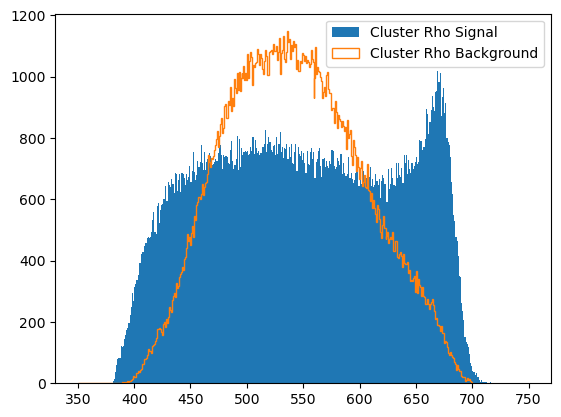

In [9]:
plt.hist(clusterrho_sig,label="Cluster Rho Signal", bins=400,range=(350,750))
plt.hist(clusterrho_back,label="Cluster Rho Background", histtype='step', bins=400,range=(350,700))
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

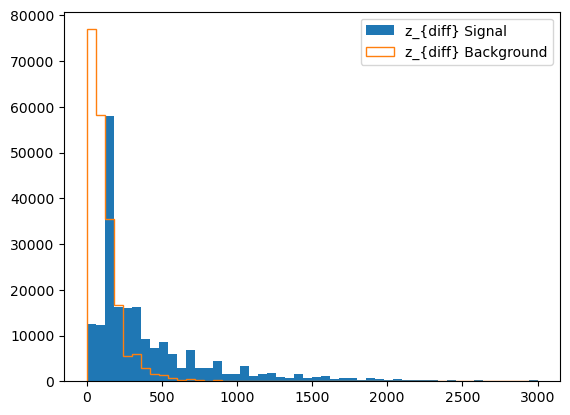

In [10]:
plt.hist(zdiff_sig,label="z_{diff} Signal", bins=50,range=(0.0,3000.0))
plt.hist(zdiff_back,label="z_{diff} Background", histtype='step', bins=50, range=(0.0,3000.0))
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

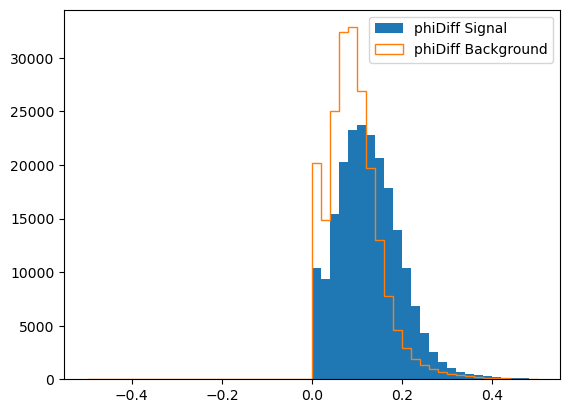

In [12]:
plt.hist(phidiff_sig,label="phiDiff Signal", bins=50,range=(-0.5,0.5))
plt.hist(phidiff_back,label="phiDiff Background", histtype='step', bins=50, range=(-0.5,0.5))
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

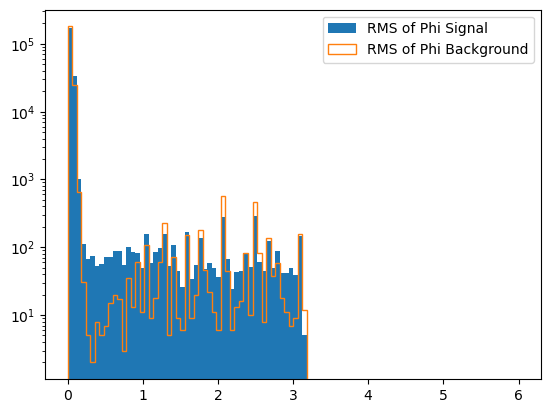

In [13]:
plt.hist(rmscphi_sig,label="RMS of Phi Signal", log=1,bins=100, range=(0.,6.0))
plt.hist(rmscphi_back,label="RMS of Phi Background",log=1, histtype='step', bins=100, range=(0.,6.0))
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

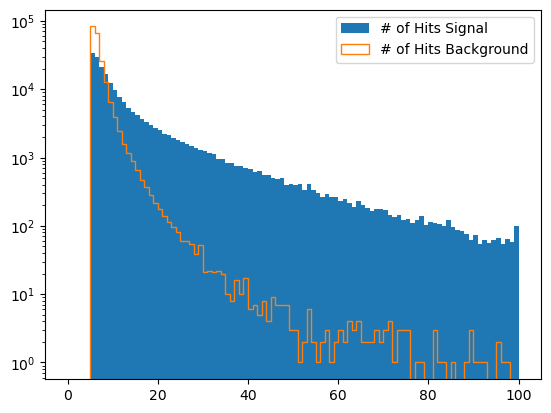

In [14]:
plt.hist(nhits_sig,label="# of Hits Signal", bins=100, range=(0.0,100.0))
plt.hist(nhits_back,label="# of Hits Background", histtype='step', bins=100, range=(0.0,100.0))
plt.yscale('log')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

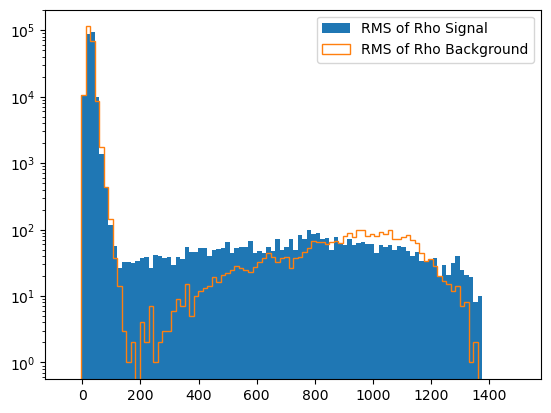

In [15]:
plt.hist(rmscrho_sig,label="RMS of Rho Signal", log=1,bins=100, range=(-50.,1500.0))
plt.hist(rmscrho_back,label="RMS of Rho Background",log=1, histtype='step', bins=100, range=(-50.,1500.0))
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

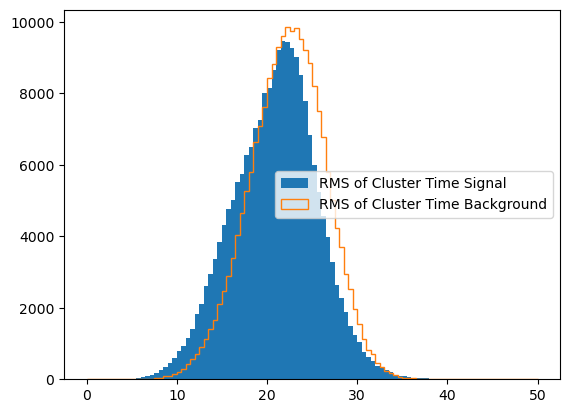

In [16]:
plt.hist(rmsctime_sig,label="RMS of Cluster Time Signal", bins=100, range=(0.0,50.0))
plt.hist(rmsctime_back,label="RMS of Cluster Time Background",histtype='step', bins=100, range=(0.0,50.0))
plt.legend()
plt.show

In [17]:
lay0=Input(shape=(n_variables,),batch_size=1)
lay1=Dense(2*n_variables, activation='relu')(lay0)
lay2=Dense(2*n_variables, activation='relu')(lay1)
lay3=Dense(2*n_variables, activation='relu')(lay2)
lay4=Dense(1,activation='sigmoid')(lay3)
output_model=Model(inputs=lay0,outputs=lay4)

opt = Adam(learning_rate=1e-3)
input=Input(shape=(n_variables,),batch_size=bsize)
x=Dense(2*n_variables, activation='relu')(input)
x=Dense(2*n_variables, activation='relu')(x)
x=Dense(2*n_variables, activation='relu')(x)
output=Dense(1,activation='sigmoid')(x)
model_ce=Model(inputs=input,outputs=output)
model_ce.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer=opt)
early_stop = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-5, restore_best_weights=True)
history_ce = model_ce.fit(x_ce_train, y_ce_train,
                          batch_size=bsize,
                          epochs=200,
                          verbose=1,
                          validation_data=(x_ce_valid, y_ce_valid),
                          callbacks=[early_stop]
                         )

Epoch 1/200
6472/6472 [==============================] - 3s 371us/step - loss: 0.5051 - accuracy: 0.7785 - val_loss: 0.4910 - val_accuracy: 0.7850
Epoch 2/200
6472/6472 [==============================] - 2s 363us/step - loss: 0.4433 - accuracy: 0.7941 - val_loss: 0.4115 - val_accuracy: 0.8091
Epoch 3/200
6472/6472 [==============================] - 2s 365us/step - loss: 0.4213 - accuracy: 0.8017 - val_loss: 0.4583 - val_accuracy: 0.7735
Epoch 4/200
6472/6472 [==============================] - 2s 372us/step - loss: 0.4037 - accuracy: 0.8113 - val_loss: 0.3961 - val_accuracy: 0.8139
Epoch 5/200
6472/6472 [==============================] - 3s 438us/step - loss: 0.3949 - accuracy: 0.8162 - val_loss: 0.3877 - val_accuracy: 0.8195
Epoch 6/200
6472/6472 [==============================] - 3s 455us/step - loss: 0.3892 - accuracy: 0.8195 - val_loss: 0.3841 - val_accuracy: 0.8234
Epoch 7/200
6472/6472 [==============================] - 2s 372us/step - loss: 0.3845 - accuracy: 0.8219 - val_loss: 0

In [18]:
model_xgboost = XGBClassifier()
model_xgboost.fit(x_ce_train, y_ce_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [19]:
#prediction_ce = model_ce.predict(x_ce_test).ravel()
prediction_ce = model_ce.predict(x_ce_test)
fpr_ce, tpr_ce, th_ce = roc_curve(y_ce_test,  prediction_ce)
auc_ce = roc_auc_score(y_ce_test, prediction_ce)

3236/3236 [==============================] - 1s 188us/step


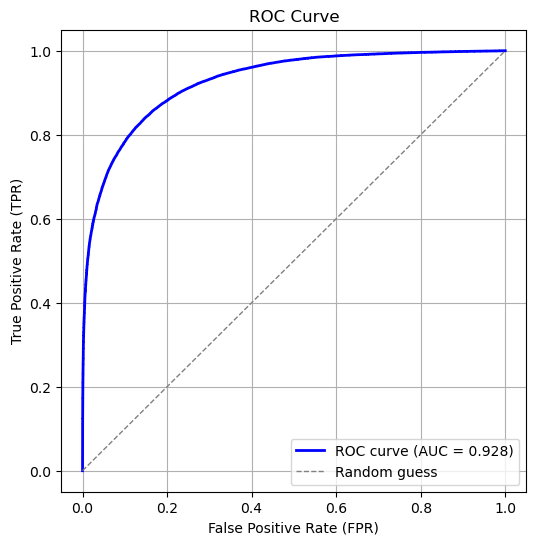

In [20]:
fpr_ce, tpr_ce, th_ce = roc_curve(y_ce_test, prediction_ce)
auc_ce = roc_auc_score(y_ce_test, prediction_ce)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr_ce, tpr_ce, color='blue', lw=2, label=f'ROC curve (AUC = {auc_ce:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [21]:
prediction_xgboost = model_xgboost.predict_proba(x_ce_test)[:,1]
fpr_xgboost, tpr_xgboost, th_xgboost = roc_curve(y_ce_test,  prediction_xgboost)
auc_xgboost = roc_auc_score(y_ce_test, prediction_xgboost)

(0.0, 1.05)

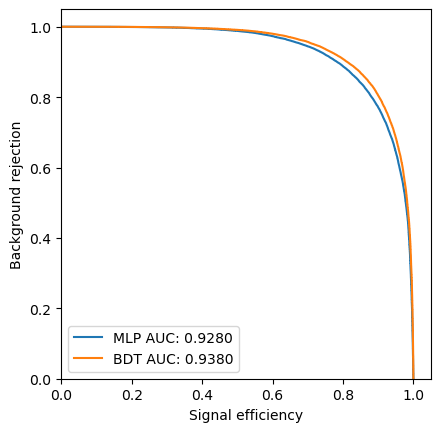

In [22]:
fig, ax = plt.subplots(1,1)
ax.plot(tpr_ce,1-fpr_ce,label=f'MLP AUC: {auc_ce:.4f}')
ax.plot(tpr_xgboost,1-fpr_xgboost,label=f'BDT AUC: {auc_xgboost:.4f}')

ax.legend()
ax.set_aspect("equal")
ax.set_xlabel("Signal efficiency")
ax.set_ylabel("Background rejection")
ax.set_xlim(0.,1.05)
ax.set_ylim(0.,1.05)
#fig.savefig("TrainBkgDiag.pdf")

(0.0, 1.05)

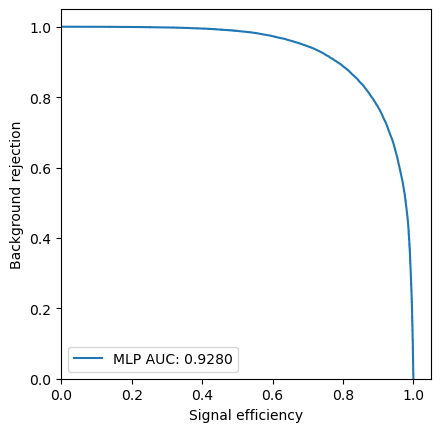

In [23]:
fig, ax = plt.subplots(1,1)
ax.plot(tpr_ce,1-fpr_ce,label=f'MLP AUC: {auc_ce:.4f}')

ax.legend()
ax.set_aspect("equal")
ax.set_xlabel("Signal efficiency")
ax.set_ylabel("Background rejection")
ax.set_xlim(0.,1.05)
ax.set_ylim(0.,1.05)
#fig.savefig("TrainBkgDiag.pdf")

In [24]:
model_ce.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(32, 8)]                 0         
                                                                 
 dense_4 (Dense)             (32, 16)                  144       
                                                                 
 dense_5 (Dense)             (32, 16)                  272       
                                                                 
 dense_6 (Dense)             (32, 16)                  272       
                                                                 
 dense_7 (Dense)             (32, 1)                   17        
                                                                 
Total params: 705 (2.75 KB)
Trainable params: 705 (2.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [25]:
output_model.set_weights(model_ce.get_weights())
output_model.summary()
#output_model.save("model/TrainBkgDiag.h5")
output_model.save("model/TrainBkgDiag.h5", save_format="h5", include_optimizer=True)
model_ce.save("TrainBkgDiag.h5")
#output_model.save("model/TrainBkgDiag.keras")

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(1, 8)]                  0         
                                                                 
 dense (Dense)               (1, 16)                   144       
                                                                 
 dense_1 (Dense)             (1, 16)                   272       
                                                                 
 dense_2 (Dense)             (1, 16)                   272       
                                                                 
 dense_3 (Dense)             (1, 1)                    17        
                                                                 
Total params: 705 (2.75 KB)
Trainable params: 705 (2.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


/Users/namithachithirasree/miniforge3/envs/root_mu2e_env/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
